In [1]:
from src import *
from myutils import *

In [2]:
clean_all_cache()

done


In [3]:
@cache
@parallelize()
def main(freq, repeat=200):
    meta = MetaData('DI', freq, 5*DMD.PIXEL_SIZE/2, 0)
    c = Simulator(meta)
    cropped_data = np.array([c.gen(400) for _ in range(repeat)])
    td = td_estimator(meta.measurement, cropped_data)
    f_est = np.array([freq_estimator(td_) for td_ in td])
    return f_est


In [4]:
f_est = main(np.linspace(0.1, 0.4, 61))

In [5]:
f_est = np.array(f_est)

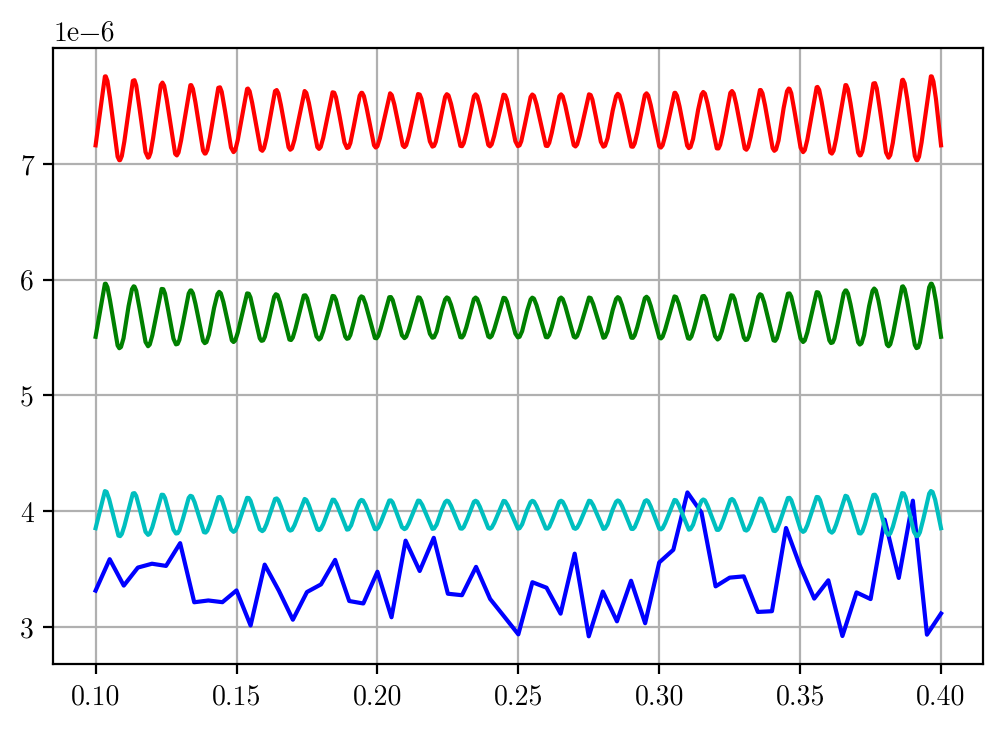

In [6]:
plot(np.linspace(0.1, 0.4, 61), f_est.var(-1) * 400)

x_axis = np.linspace(0.1, 0.4, 1000)
crb = (1 / FisherInformation([5 * DMD.PIXEL_SIZE / 2], x_axis))[0]

plot(x_axis, crb)
plot(x_axis, 1.3 * crb)
plot(x_axis, 0.7 * crb)

In [7]:
f_est.mean(-1)

array([0.10134243, 0.10504673, 0.11011017, 0.1150254 , 0.12030459,
       0.12693146, 0.12979081, 0.13479498, 0.14020274, 0.14499784,
       0.15065709, 0.15493881, 0.16045652, 0.16420972, 0.16926519,
       0.17558299, 0.18007623, 0.1851785 , 0.18996988, 0.19489084,
       0.20144938, 0.20508573, 0.21006098, 0.21553274, 0.22026795,
       0.22562637, 0.23027774, 0.23529185, 0.24069044, 0.24626422,
       0.25373075, 0.25373845, 0.25962962, 0.26470447, 0.26972355,
       0.27510077, 0.28003961, 0.28448276, 0.28991812, 0.2949043 ,
       0.30140503, 0.30510344, 0.31003759, 0.31482034, 0.32024585,
       0.32515607, 0.33077236, 0.33582116, 0.33986446, 0.34507711,
       0.35059614, 0.35499099, 0.3601221 , 0.36523228, 0.37020239,
       0.37683453, 0.37999513, 0.38499144, 0.38990362, 0.39495799,
       0.40153457])